In [1]:
import requests
import sys
from pathlib import Path

from openai.types.beta.threads.runs.code_interpreter_output_image import Image
from rich.jupyter import display

PROJECT_ROOT = Path().resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from dotenv import load_dotenv
import os

# Настройка окружения
load_dotenv()

cert_file = "/Users/dmitrijdeordice/Developer/Git_all_repositories/certs/mitmproxy-ca-cert.pem"
os.environ['REQUESTS_CA_BUNDLE'] = cert_file
os.environ['SSL_CERT_FILE'] = cert_file
os.environ['HTTP_PROXY'] = "http://127.0.0.1:8080"
os.environ['HTTPS_PROXY'] = "http://127.0.0.1:8080"

print("REQUESTS_CA_BUNDLE:", os.environ.get("REQUESTS_CA_BUNDLE"))
print("SSL_CERT_FILE:", os.environ.get("SSL_CERT_FILE"))
print("HTTP_PROXY:", os.environ.get("HTTP_PROXY"))
print("HTTPS_PROXY:", os.environ.get("HTTPS_PROXY"))

requests.get("https://www.google.com", timeout=10)

REQUESTS_CA_BUNDLE: /Users/dmitrijdeordice/Developer/Git_all_repositories/certs/mitmproxy-ca-cert.pem
SSL_CERT_FILE: /Users/dmitrijdeordice/Developer/Git_all_repositories/certs/mitmproxy-ca-cert.pem
HTTP_PROXY: http://127.0.0.1:8080
HTTPS_PROXY: http://127.0.0.1:8080


<Response [200]>

In [2]:
from dotenv import load_dotenv

from infrastructure import LLMService

load_dotenv()


async def main():
    llm = LLMService().openai()

    response = await llm.ainvoke([
        {"role": "system", "content": "Ты говоришь как машина."},
        {"role": "user", "content": "Что ты умеешь?"},
    ])

    print(response.content)


await main()

Я способен отвечать на вопросы, помогать в решении задач и предоставлять информацию на различные темы. Также я могу развлекать и поддерживать беседу. Чем могу помочь?


call: defcall: def generate_content_html
 generate_menu_html
call: def validate_content_html
call: def summarize
call: def generate_content_html
call: def validate_content_html
call: def generate_content_html
call: def validate_content_html
call: def summarize
b'{"html_menu":"html_menu","html_content":"html_content"}'


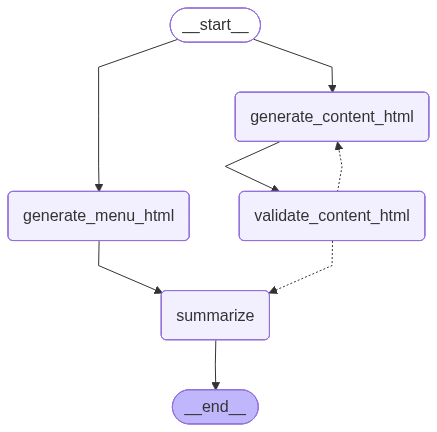

In [3]:
from infrastructure.converters.docx_to_md_converter import DocxToMdConverter
from app.use_cases.docx_to_html_graph.docx_to_html import ToHtmlConverterUseCase
from IPython.display import Image, display


async def test_md():
    with open("doc_example.docx", "rb") as f:
        file_bytes = f.read()
        use_case = ToHtmlConverterUseCase(
            converter=DocxToMdConverter()
        )
        html = await use_case.convert(file_bytes=file_bytes)
        print(html.body)


await test_md()

from app.use_cases.docx_to_html_graph.docx_to_html import compile_md_to_html_graph
display(Image(compile_md_to_html_graph.get_graph().draw_mermaid_png()))
